#Classificação com QDA, LDA e SVM

## Objetivo e justificativa

**Variável-alvo:** `NumberOfDependents` — variável inteira que indica o número de dependentes do requerente de crédito.

**Justificativa da escolha do alvo:** Em relação à variável `SeriousDlqin2yrs`, no conjunto de teste ela apresenta um comportamento probabilístico. No entanto, a natureza dos classificadores QDA, LDA  e SVM são puramente categórica — ou seja, eles não atribuem uma probabilidade contínua a cada decisão. Por isso, optamos por utilizar esses modelos para prever `NumberOfDependents`, criando uma nova coluna que a representa em faixas.



## Bibliotecas

In [ ]:
#Biblioteca usuais
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
# Importa classificadores baseados em análise discriminante (linear e quadrática)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Importa funções para calcular métricas de desempenho (acurácia e matriz de confusão)
from sklearn.metrics import accuracy_score, confusion_matrix

# Ferramentas para dividir dados em treino/teste e buscar melhores hiperparâmetros (GridSearch)
from sklearn.model_selection import train_test_split, GridSearchCV

# Criação de pipelines que encadeiam etapas de pré-processamento e modelagem
from sklearn.pipeline import make_pipeline

# Ferramenta de padronização de dados (transforma features para média 0 e desvio 1)
from sklearn.preprocessing import StandardScaler

# Importa o classificador SVM (máquina de vetores de suporte)
from sklearn.svm import SVC

# Outras métricas de avaliação: acurácia, matriz de confusão, relatório de classificação
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)

## Preparação dos dados

In [ ]:
#Carregamento dos dados

treino = pd.read_csv('../final_data/treino.csv') # dados de treino
teste = pd.read_csv('../final_data/teste.csv') # dados de teste

In [ ]:
#colunas originais do banco de dados

treino.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [ ]:
#listas auxiliares
class_lista_test = []
class_lista_treino = []

#Preechimento das listas auxiliares, com variáveis categóricas
for i in range(len(treino)):
  if treino.loc[i, 'NumberOfDependents'] == 0:
    class_lista_treino.append("0 dependents")
  elif treino.loc[i, 'NumberOfDependents'] == 1:
    class_lista_treino.append("1 dependent")
  elif treino.loc[i, 'NumberOfDependents'] == 2:
    class_lista_treino.append("2 ddependents")
  else:
    class_lista_treino.append("3+ dependents")

for i in range(len((teste))):
  if teste.loc[i, 'NumberOfDependents'] == 0:
    class_lista_test.append("0 dependents")
  elif teste.loc[i, 'NumberOfDependents'] == 1:
    class_lista_test.append("1 dependent")
  elif teste.loc[i, 'NumberOfDependents'] == 2:
    class_lista_test.append("2 ddependents")
  else:
    class_lista_test.append("3+ dependents")

#Associação das listas auxiliares a nosso conjunto de dados de treino e teste
treino['NumberOfDependents_adapted'] = class_lista_treino
teste['NumberOfDependents_adapted'] = class_lista_test

A nova coluna `NumberOfDependents_adapted` será a coluna que iremos usar para treinar os modelos. A nova coluna tem um comportamento categórico como era almejado.

Abaixo, separamos as colunas que vamos utilizar para treino e teste. Após isso, reescalamos nossas variáveis para evitar erros numéricos posteriores.

In [ ]:

X_train = treino.drop(['SeriousDlqin2yrs', 'NumberOfDependents_adapted', 'NumberOfDependents'], axis=1)
y_train = treino['NumberOfDependents_adapted']

X_test = teste.drop(['SeriousDlqin2yrs', 'NumberOfDependents_adapted', 'NumberOfDependents'], axis=1)
y_test = teste['NumberOfDependents_adapted']

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#LDA

Feito,

In [ ]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

print("Acurácia do Treino:", accuracy_score(y_train, lda.predict(X_train)))
print("Acurácia do Teste:", accuracy_score(y_test, lda.predict(X_test)))

Acurácia do Treino: 0.5931090665133218
Acurácia do Teste: 0.5909261001041698


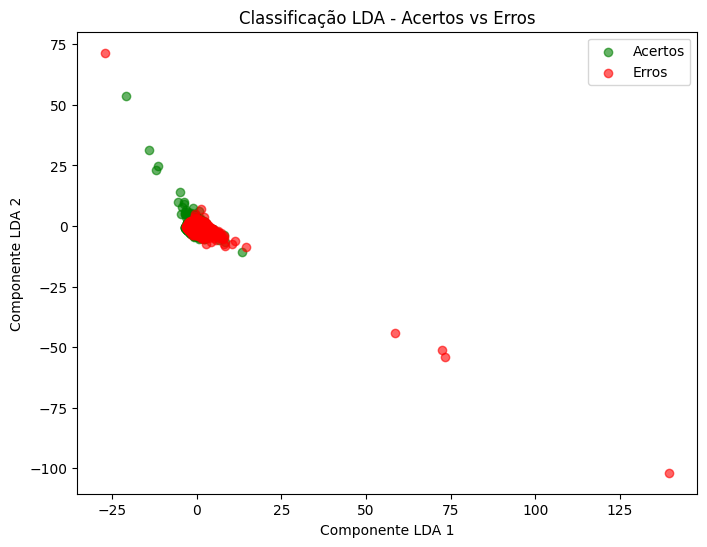

In [ ]:
acertos = lda.predict(X_test) == y_test
erros = ~acertos


X_lda = lda.transform(X_test)

# Plotando
plt.figure(figsize=(8,6))
plt.scatter(X_lda[acertos, 0], X_lda[acertos, 1], color='green', label='Acertos', alpha=0.6)
plt.scatter(X_lda[erros, 0], X_lda[erros, 1], color='red', label='Erros', alpha=0.6)
plt.title('Classificação LDA - Acertos vs Erros')
plt.xlabel('Componente LDA 1')
plt.ylabel('Componente LDA 2')
plt.legend()
plt.show()

#QDA

In [ ]:
'''
k = 0
right_param = 0

for i in range(1, 1001):
  qda = QuadraticDiscriminantAnalysis(reg_param = i/1000)
  qda.fit(X_train, y_train)
  print(i)
  if accuracy_score(y_train, qda.predict(X_train)) > k:
    k = accuracy_score(y_train, qda.predict(X_train))
    right_param = i/1000


print("Best score:", k)
print("Best param:", right_param)
'''

'''
Best score: 0.5112311255398121
Best param: 0.943
'''


qda = QuadraticDiscriminantAnalysis(reg_param = 0.943)
qda.fit(X_train, y_train)

QuadraticDiscriminantAnalysis(reg_param=0.943)

In [ ]:
print("Acurácia do Treino:", accuracy_score(y_train, qda.predict(X_train)))
print("Acurácia do Teste:", accuracy_score(y_test, qda.predict(X_test)))

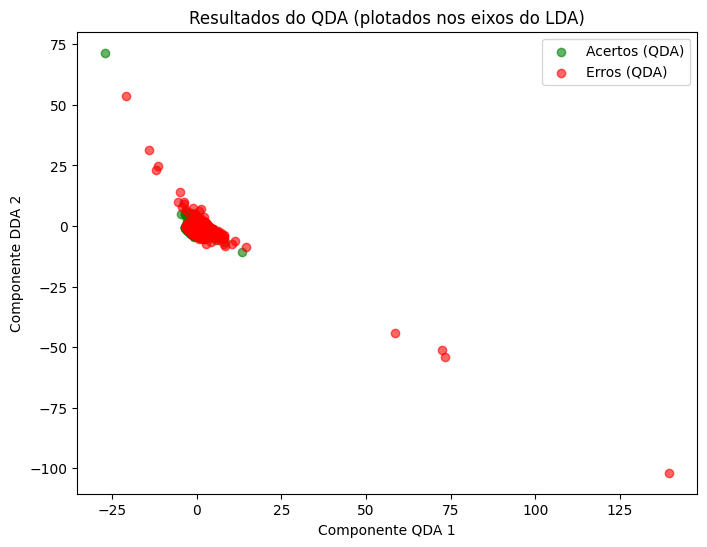

In [ ]:

y_pred_qda = qda.predict(X_test)
acertos_qda = (y_pred_qda == y_test)
erros_qda = ~acertos_qda

X_lda_eixos = lda.transform(X_test)

plt.figure(figsize=(8,6))
plt.scatter(X_lda_eixos[acertos_qda, 0], X_lda_eixos[acertos_qda, 1], color='green', label='Acertos (QDA)', alpha=0.6)
plt.scatter(X_lda_eixos[erros_qda, 0], X_lda_eixos[erros_qda, 1], color='red', label='Erros (QDA)', alpha=0.6)
plt.title('Resultados do QDA (plotados nos eixos do LDA)')
plt.xlabel('Componente QDA 1')
plt.ylabel('Componente DDA 2')
plt.legend()
plt.show()

# SVM

In [ ]:
param_grid = {'C': [0.1, 1, 2, 10]}

In [ ]:
grid = GridSearchCV(
    SVC(kernel='rbf', max_iter=1000),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print("Melhor score CV:", grid.best_score_)
print("Melhores parâmetros:", grid.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Melhor score CV: 0.3274665242750349
Melhores parâmetros: {'C': 1}


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [ ]:
best = grid.best_estimator_
y_pred = best.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

Accuracy: 0.2688491762492794
               precision    recall  f1-score   support

 0 dependents       0.68      0.25      0.37     58618
  1 dependent       0.18      0.30      0.23     17618
2 ddependents       0.16      0.03      0.04     13298
3+ dependents       0.13      0.64      0.22      9343

     accuracy                           0.27     98877
    macro avg       0.29      0.31      0.22     98877
 weighted avg       0.47      0.27      0.29     98877

Confusion matrix:
 [[14878 19781  1216 22743]
 [ 3196  5346   365  8711]
 [ 2155  2404   345  8394]
 [ 1589  1528   212  6014]]


In [ ]:
grid = GridSearchCV(
    SVC(kernel='linear', max_iter=1000),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print("Melhor score CV:", grid.best_score_)
print("Melhores parâmetros:", grid.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Melhor score CV: 0.15824639228894546
Melhores parâmetros: {'C': 10}


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [ ]:
best = grid.best_estimator_
y_pred = best.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

Accuracy: 0.10432153079078046
               precision    recall  f1-score   support

 0 dependents       0.77      0.01      0.01     58618
  1 dependent       0.21      0.06      0.10     17618
2 ddependents       0.17      0.01      0.02     13298
3+ dependents       0.09      0.93      0.17      9343

     accuracy                           0.10     98877
    macro avg       0.31      0.25      0.08     98877
 weighted avg       0.53      0.10      0.04     98877

Confusion matrix:
 [[  341  3056   444 54777]
 [   61  1134   187 16236]
 [   23   732   157 12386]
 [   18   510   132  8683]]


# Resultados

| Modelo           | Acurácia                               | Tipo     |
|------------------|----------------------------------------|----------|
| LDA              | I                    | Numérica |
| Age              | Idade do requerente                    | Numérica |
| Income           | Renda mensal do requerente             | Numérica |
| SeriousDlqin2yrs | Inadimplência séria em 2 anos (alvo)   | Binária  |